# Reproducing the figures of the CRC dataset analysis with **minkiPy**

This notebook is designed to **reproduce the figures presented in the paper** using the **minkiPy** framework. It provides a complete and reproducible workflow.

The notebook performs the following steps:

1. **Download the raw CRC dataset** used in the study.
2. **Compute Minkowski profiles** using the **minkiPy** pipeline.
3. **Run the downstream analysis** and **generate the figures**.

### Download and extract the raw CRC dataset

The following cell downloads the **raw CRC dataset used in the paper** from the 10x Genomics website and extracts it locally.  

The five `tar.gz` archives are downloaded into the `raw_data/` directory, extracted in place, and then removed after successful extraction.

In [1]:
from pathlib import Path
import requests
import tarfile

samples = {
    "P1_CRC": "https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Cancer_P1/Visium_HD_Human_Colon_Cancer_P1_binned_outputs.tar.gz",
    "P2_CRC": "https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Cancer_P2/Visium_HD_Human_Colon_Cancer_P2_binned_outputs.tar.gz",
    "P5_CRC": "https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Cancer_P5/Visium_HD_Human_Colon_Cancer_P5_binned_outputs.tar.gz",
    "P3_NAT": "https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Normal_P3/Visium_HD_Human_Colon_Normal_P3_binned_outputs.tar.gz",
    "P5_NAT": "https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Normal_P5/Visium_HD_Human_Colon_Normal_P5_binned_outputs.tar.gz",
}

out_dir = Path("examples/CRC_dataset/raw_data")
out_dir.mkdir(parents=True, exist_ok=True)

chunk_size = 1024 * 1024  # 1 MB

for sample_name, url in samples.items():
    sample_dir = out_dir / sample_name
    sample_dir.mkdir(parents=True, exist_ok=True)

    filename = url.split("/")[-1]
    tar_path = sample_dir / filename

    print(f"\nDownloading {sample_name}...")

    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        downloaded = 0

        with open(tar_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total > 0:
                        pct = 100 * downloaded / total
                        print(
                            f"\rDownloaded {downloaded / 1e9:.2f} / {total / 1e9:.2f} GB ({pct:.1f}%)",
                            end=""
                        )

    print("\nDownload finished.")

    print(f"Extracting into {sample_dir} ...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=sample_dir)

    print(f"Extracted to: {sample_dir.resolve()}")

    tar_path.unlink()
    print(f"Removed archive: {tar_path.resolve()}")

print("\nAll CRC datasets were downloaded and extracted successfully.")


Downloaded 12.32 / 12.32 GB (100.0%)
Download finished.
Extracting into examples/CRC_dataset/raw_data/P1_CRC ...
Extracted to: /mnt/DATA_11TB/projects/Spatial_Transcriptomics/minkiPy/minkiPy_package/examples/CRC_dataset/raw_data/P1_CRC
Removed archive: /mnt/DATA_11TB/projects/Spatial_Transcriptomics/minkiPy/minkiPy_package/examples/CRC_dataset/raw_data/P1_CRC/Visium_HD_Human_Colon_Cancer_P1_binned_outputs.tar.gz

Downloaded 15.89 / 15.89 GB (100.0%)
Download finished.
Extracting into examples/CRC_dataset/raw_data/P2_CRC ...
Extracted to: /mnt/DATA_11TB/projects/Spatial_Transcriptomics/minkiPy/minkiPy_package/examples/CRC_dataset/raw_data/P2_CRC
Removed archive: /mnt/DATA_11TB/projects/Spatial_Transcriptomics/minkiPy/minkiPy_package/examples/CRC_dataset/raw_data/P2_CRC/Visium_HD_Human_Colon_Cancer_P2_binned_outputs.tar.gz

Downloaded 8.00 / 16.57 GB (48.3%)Extracted to: /mnt/DATA_11TB/projects/Spatial_Transcriptomics/minkiPy/minkiPy_package/examples/CRC_dataset/raw_data/P5_CRC
Removed 

## Preprocessing of the Visium HD CRC dataset and Minkowski profile estimation

In this step, we load the **raw Visium HD data** for the CRC and matched normal samples and convert them into the transcript-level format expected by `minkiPy`.

The preprocessing consists of:
- loading the **2 µm binned expression matrix** for each sample,
- importing the associated spatial coordinates,
- converting pixel coordinates into **micron-scale spatial coordinates**,
- filtering genes to retain only those with sufficient total transcript support.

After preprocessing, each spot is expanded into a transcript-level table with the columns `gene`, `global_x`, and `global_y`.  
We then compute **Minkowski profiles** for each sample using `minkiPy`, and write the resulting outputs to disk for downstream analysis.

In [ ]:
def user_preprocessing_VISIUM(name):
    import scanpy as sc
    import pandas as pd
    import numpy as np
    import json
    from scipy.sparse import issparse
    from tqdm import tqdm

    adata_full = sc.read_10x_h5(
        f"examples/CRC_dataset/raw_data/{name}/binned_outputs/square_002um/filtered_feature_bc_matrix.h5"
    )
    adata_full.var_names_make_unique()

    tissue_positions = pd.read_parquet(
        f"examples/CRC_dataset/raw_data/{name}/binned_outputs/square_002um/spatial/tissue_positions.parquet"
    )
    tissue_positions.set_index("barcode", inplace=True)
    adata_full.obs = adata_full.obs.merge(
        tissue_positions[["pxl_row_in_fullres", "pxl_col_in_fullres"]],
        left_index=True,
        right_index=True,
        how="left"
    )
    adata_full.obs["pxl_col_in_fullres"] -= adata_full.obs["pxl_col_in_fullres"].min()
    adata_full.obs["pxl_row_in_fullres"] = -adata_full.obs["pxl_row_in_fullres"]
    adata_full.obs["pxl_row_in_fullres"] -= adata_full.obs["pxl_row_in_fullres"].min()

    with open(
        f"examples/CRC_dataset/raw_data/{name}/binned_outputs/square_002um/spatial/scalefactors_json.json",
        "r"
    ) as f_:
        data_sf = json.load(f_)

    adata_full.obs["pxl_col_in_fullres"] *= data_sf['microns_per_pixel']
    adata_full.obs["pxl_row_in_fullres"] *= data_sf['microns_per_pixel']
    adata_full.obs.rename(
        columns={
            'pxl_col_in_fullres': 'global_x',
            'pxl_row_in_fullres': 'global_y'
        },
        inplace=True
    )
    bin_size_um = data_sf['bin_size_um']
    #area_mask = bin_size_um**2 * len(adata_full.obs['global_x'].values)

    # Filter genes by total transcript count (sum across all spots)
    # Works on sparse or dense arrays
    X = adata_full.X
    if issparse(X):
        total_transcripts_per_gene = np.array(X.sum(axis=0)).flatten()
    else:
        total_transcripts_per_gene = X.sum(axis=0).flatten()


    # Keep genes with (1) total transcripts >= 50 AND (2) observed in >= 1 spots ("pixels")
    MIN_COUNTS = 100
    MIN_SPOTS  = 1

    # Count non-zero spots per gene
    if issparse(X):
        # fast per-column nnz for CSR via CSC indptr
        X_csc = X.tocsc()
        observed_spots_per_gene = np.diff(X_csc.indptr)
    else:
        observed_spots_per_gene = np.count_nonzero(X, axis=0).flatten()

    mask = (total_transcripts_per_gene >= MIN_COUNTS) & (observed_spots_per_gene >= MIN_SPOTS)
    genes_kept_idx = np.where(mask)[0]
    gene_list = adata_full.var_names[genes_kept_idx].tolist()


    # Restrict AnnData object to selected genes
    adata = adata_full[:, gene_list].copy()
    obs = adata.obs.reset_index(drop=True)

    X = adata.X
    if not issparse(X):
        from scipy.sparse import csr_matrix
        X = csr_matrix(X)

    genes = []
    xs = []
    ys = []

    # tqdm progress bar
    for spot_idx in tqdm(range(X.shape[0]),desc="Processing spots",unit="spot",mininterval=5.0,disable=False):
        row = X.getrow(spot_idx)
        spot_x = obs.loc[spot_idx, "global_x"]
        spot_y = obs.loc[spot_idx, "global_y"]
        genes_idx = row.indices
        counts = row.data.astype(int)
        for idx, count in zip(genes_idx, counts):
            gene = gene_list[idx]
            genes.extend([gene] * count)
            xs.extend([spot_x] * count)
            ys.extend([spot_y] * count)

    transcripts = pd.DataFrame({'gene': genes, 'global_x': xs, 'global_y': ys})

    del adata_full
    return transcripts


import minkiPy
import os
names = ['P1_CRC','P2_CRC','P3_NAT','P5_CRC','P5_NAT']

for name in names:
    df= user_preprocessing_VISIUM(name)
    
    outdir = "examples/CRC_dataset/minkiPy_results_CRC_full_analysis"
    os.makedirs(outdir, exist_ok=True)
    
    h5 = minkiPy.compute_Minkowski_profiles(
        df,
        name=name,
        output_path=outdir,
        resolution=20.0,
        nbr=20,
        overwrite=True,
        mpi_procs=60, # adapt this line to the number of threads you want to use
        use_hwthreads=True,
    )

/home/baratta/.conda/envs/minkiPy/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/baratta/.conda/envs/minkiPy/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
Processing spots: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 8115564/8115564 [04:11<00:00, 32294.39spot/s]


[Rank 59] local_data shape = (570072, 3), #genes = 240
[Rank 9] local_data shape = (1289427, 3), #genes = 241
[Rank 13] local_data shape = (1383144, 3), #genes = 241
[Rank 55] local_data shape = (1922255, 3), #genes = 240
[Rank 7] local_data shape = (1240277, 3), #genes = 241
[Rank 48] local_data shape = (1797632, 3), #genes = 240
[Rank 49] local_data shape = (1520107, 3), #genes = 240
[Rank 17] local_data shape = (973037, 3), #genes = 241
[Rank 33] local_data shape = (1302220, 3), #genes = 240
[Rank 32] local_data shape = (1714127, 3), #genes = 240
[Rank 51] local_data shape = (1490569, 3), #genes = 240
[Rank 41] local_data shape = (1297881, 3), #genes = 240
[Rank 58] local_data shape = (571112, 3), #genes = 240
[Rank 25] local_data shape = (1096719, 3), #genes = 241
[Rank 45] local_data shape = (1132756, 3), #genes = 240
[Rank 3] local_data shape = (1385785, 3), #genes = 241
[Rank 57] local_data shape = (1386700, 3), #genes = 240
[Rank 29] local_data shape = (1536734, 3), #genes = 24

/home/baratta/.conda/envs/minkiPy/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/baratta/.conda/envs/minkiPy/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
Processing spots:  99%|████████████████████████████████████████████████████████████████████████████████████████████████████▎| 8672129/8731400 [05:04<00:02, 28587.24spot/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Loading merged minkiPy outputs for downstream analysis

We now load the merged `minkiPy` output files for the **CRC** and **NAT** samples.  
At this stage, `process_data` assembles the Minkowski profiles, gene densities, and dataset annotations into a single in-memory object.

We also define the dataset ordering and the grouping of samples into **CRC** and **NAT** conditions.  
In addition, we apply a post-loading filter to retain only genes with at least **1000 transcripts in at least one sample**.

In [1]:
import minkiPy

ordered_conditions = ['P1_CRC','P2_CRC','P3_NAT','P5_CRC','P5_NAT']
groups = {
    "CRC": [0, 1, 3], #with respect to ordered_conditions
    "NAT": [2, 4]
}

filepaths = [
    'examples/CRC_dataset/minkiPy_results_CRC_full_analysis/minkiPy_merged_resolution_20_P5_NAT.h5',
    'examples/CRC_dataset/minkiPy_results_CRC_full_analysis/minkiPy_merged_resolution_20_P5_CRC.h5',
    'examples/CRC_dataset/minkiPy_results_CRC_full_analysis/minkiPy_merged_resolution_20_P3_NAT.h5',
    'examples/CRC_dataset/minkiPy_results_CRC_full_analysis/minkiPy_merged_resolution_20_P2_CRC.h5',
    'examples/CRC_dataset/minkiPy_results_CRC_full_analysis/minkiPy_merged_resolution_20_P1_CRC.h5',
]

data = minkiPy.process_data(
    filepaths,
    ordered_conditions=ordered_conditions, 
    groups=groups,
    min_transcripts_any_sample=1000,
    verbose=True,
)

[load] Found 5 non-subsampled merged files.
  - #00 | dataset=P1_CRC | resolution=20 | file=minkiPy_merged_resolution_20_P1_CRC.h5
  - #01 | dataset=P2_CRC | resolution=20 | file=minkiPy_merged_resolution_20_P2_CRC.h5
  - #02 | dataset=P3_NAT | resolution=20 | file=minkiPy_merged_resolution_20_P3_NAT.h5
  - #03 | dataset=P5_CRC | resolution=20 | file=minkiPy_merged_resolution_20_P5_CRC.h5
  - #04 | dataset=P5_NAT | resolution=20 | file=minkiPy_merged_resolution_20_P5_NAT.h5
[inspect] Common level-set grid with 20 levels; 13792 genes shared across all datasets.
[gene-filter] Applying transcript-count filter: retain genes with max_i n_transcripts[i, g] >= 1000.
[gene-filter] Retained 12649/13792 genes after transcript-count filtering.
[inspect] Common Monte Carlo depth: 122.
[load] Loaded arrays for 5 datasets, 12649 genes, 4 statistics and 20 level sets.
[load] Missing 'number_of_transcripts' entries: 0.
[load] Missing or unreadable 'area_LS0' entries: 0.
[load] 'area_mask' available fo

## Sample-to-sample distances

This cell computes **pairwise sample distances** across all datasets.  
Here we use the **diagonal covariance-aware Wasserstein distance** to compare samples from their gene-level Minkowski representations.

In [2]:
data = minkiPy.compute_sample_distances(data, diag_only=True, dataset_pairs="ALL", verbose=True)


[distance] Computing averaged sample distances for 10 dataset pairs (datasets=5, genes=12649, feature_dim=80, mode=diagonal Wasserstein approximation, ridge=1e-06, transcript_weighting=on).


sample-distance(dataset pairs):   0%|          | 0/10 [00:00<?, ?it/s]

[distance] Completed 10 dataset pairs (mode=diag-only Wasserstein, pairs_with_values=10, all_nan=0, finite_averages=10, nan_averages=0).
[distance] Per-gene distances cached in 'sample_distance_per_gene' with shape (5, 5, 12649).


## Sample-level visualisation

This cell visualises **relationships between samples** using the computed distance matrix and low-dimensional embeddings.  
It shows sample-level **MDS**, **PCA**, **UMAP**, and a PCA based on **normalised gene densities**.

/home/baratta/.conda/envs/minkiPy/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/baratta/.conda/envs/minkiPy/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


{'fig_w2': <Figure size 680x620 with 1 Axes>,
 'ax_w2': <Axes: title={'center': 'Sample-level MDS based on distance matrix'}, xlabel='MDS 1 (EVR = 42.3%)', ylabel='MDS 2 (EVR = 23.8%)'>,
 'fig_pca': <Figure size 680x620 with 1 Axes>,
 'ax_pca': <Axes: title={'center': 'Sample-level PCA based on Minkowski profiles'}, xlabel='PC1 (EVR = 36.9%)', ylabel='PC2 (EVR = 24.2%)'>,
 'fig_umap': <Figure size 680x620 with 1 Axes>,
 'ax_umap': <Axes: title={'center': 'Sample-level UMAP based on Minkowski profiles'}, xlabel='UMAP 1', ylabel='UMAP 2'>,
 'fig_pca_density': <Figure size 680x620 with 1 Axes>,
 'ax_pca_density': <Axes: title={'center': 'Sample-level PCA based on normalised densities'}, xlabel='PC1 (EVR = 74.4%)', ylabel='PC2 (EVR = 21.3%)'>,
 'mds_evr': array([0.42277587, 0.23779113]),
 'pca_evr': array([0.3689387 , 0.24192234, 0.21248029, 0.17665866]),
 'pca_density_evr': array([0.74353347, 0.21340985, 0.02488308, 0.0181736 ]),
 'labels_kept': ['P1_CRC', 'P2_CRC', 'P3_NAT', 'P5_CRC', 'P

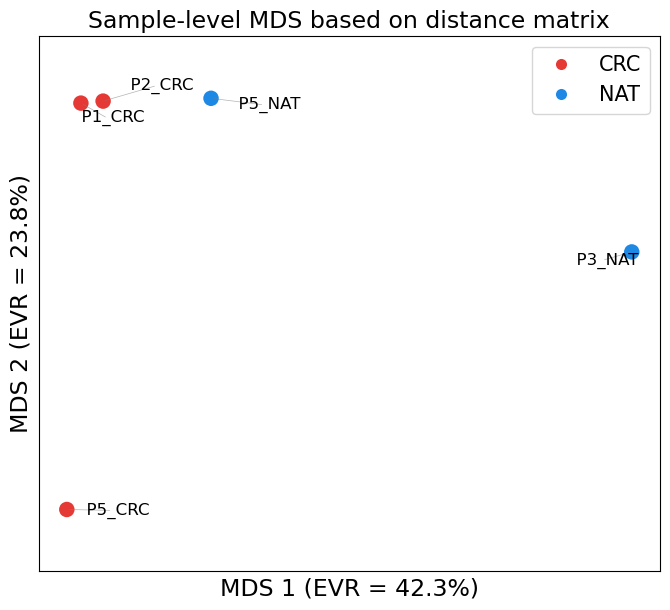

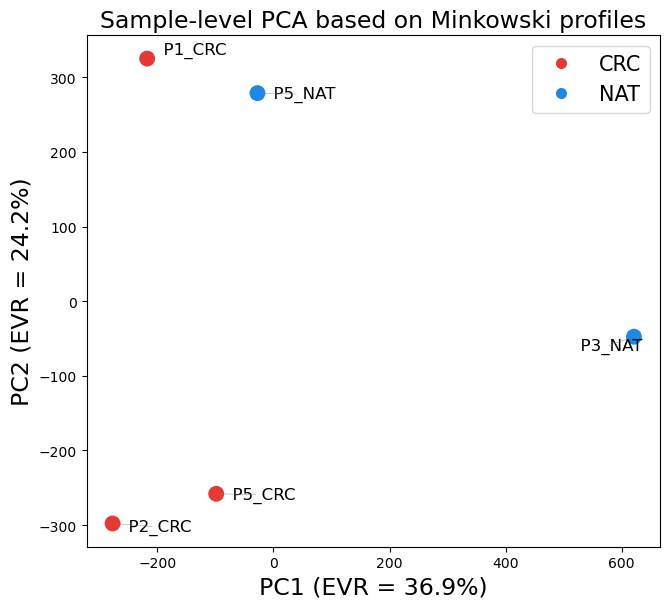

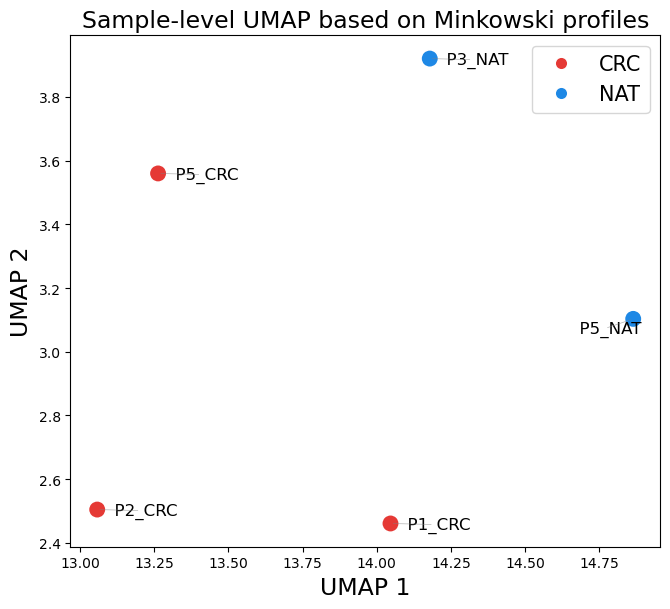

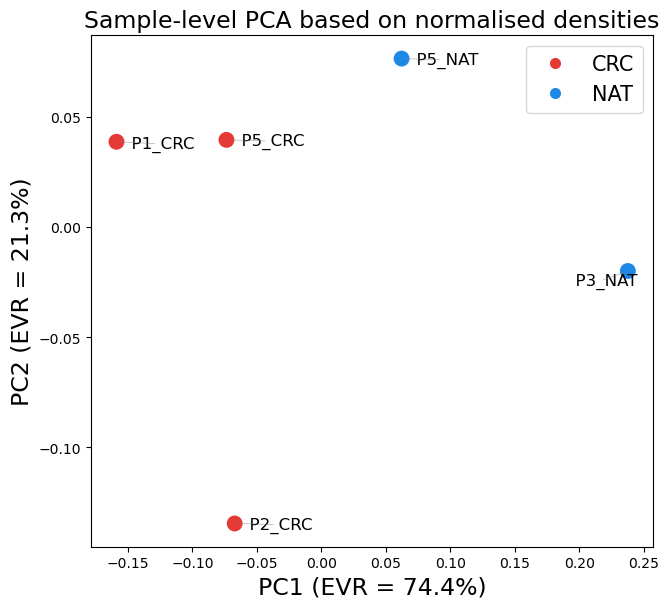

In [3]:
group_colors = {
    "NAT": "#1E88E5",
    "CRC": "#E53935",
}

minkiPy.plot_dataset_graphs_from_data(
    data,
    ordered_conditions=ordered_conditions,
    groups=groups,
    group_colors=group_colors,
    avg_darken_factor=0.72,
    show_others=False,
    label_fontsize=12.0,
    edge_label_fontsize=9.0,
    legend_loc_w2="best",
    legend_loc_pca="best",
    marker_size=160.0,
    random_seed=0,
    umap_n_neighbors=5,
    umap_min_dist=0.05,
    umap_repulsion_strength=1.2,
    umap_parallel=True,
    include_density_pca=True,
    out_pdf_w2="examples/CRC_dataset/fig1.pdf",
    out_pdf_pca="examples/CRC_dataset/fig2.pdf",
    out_pdf_umap="examples/CRC_dataset/fig3.pdf",
)

## Focusing on the P5 pair for a targeted comparison

We now restart the downstream analysis with only the two **P5 samples**, **P5_CRC** and **P5_NAT**.  
This restricted setup focuses on the main pair highlighted in the paper and applies a stricter gene filter, retaining only genes with at least **2000 transcripts in at least one sample**.

In [4]:
ordered_conditions = ['P5_CRC','P5_NAT']
groups = {
    "CRC": [0],
    "NAT": [1]
}

filepaths = [
    'examples/CRC_dataset/minkiPy_results_CRC_full_analysis/minkiPy_merged_resolution_20_P5_CRC.h5',
    'examples/CRC_dataset/minkiPy_results_CRC_full_analysis/minkiPy_merged_resolution_20_P5_NAT.h5']

data = minkiPy.process_data(
    filepaths,
    ordered_conditions=ordered_conditions, 
    groups=groups, 
    min_transcripts_any_sample=2000,
    verbose=True,
)

[load] Found 2 non-subsampled merged files.
  - #00 | dataset=P5_CRC | resolution=20 | file=minkiPy_merged_resolution_20_P5_CRC.h5
  - #01 | dataset=P5_NAT | resolution=20 | file=minkiPy_merged_resolution_20_P5_NAT.h5
[inspect] Common level-set grid with 20 levels; 17123 genes shared across all datasets.
[gene-filter] Applying transcript-count filter: retain genes with max_i n_transcripts[i, g] >= 2000.
[gene-filter] Retained 11204/17123 genes after transcript-count filtering.
[inspect] Common Monte Carlo depth: 122.
[load] Loaded arrays for 2 datasets, 11204 genes, 4 statistics and 20 level sets.
[load] Missing 'number_of_transcripts' entries: 0.
[load] Missing or unreadable 'area_LS0' entries: 0.
[load] 'area_mask' available for 2/2 datasets.
[scale] Applied robust scaling (per statistic).
[cov] Estimating covariance matrices in D=80 dimensions; MC threshold = 121.
[cov] Completed covariance estimation for 22408 dataset-gene pairs.
[density] Computed 22408/22408 finite raw densities;

## Gene-pair distances for the P5 comparison

This cell computes **gene-pair distances** between **P5_CRC** and **P5_NAT**.  
Here we use the **diagonal covariance-aware Wasserstein distance** and also store the corresponding **Euclidean distances** for comparison.

In [5]:
data = minkiPy.compute_gene_distances(
    data,
    datasets=["P5_CRC", "P5_NAT"],
    diag_only=True,
    add_euclidean=True,
)

[gene-distance] Computing diag-only Wasserstein distances for 2 datasets, 11204 genes, feature_dim=80, ridge=1e-08.
[gene-distance] Euclidean gene-pair distances will also be stored.


gene distances:   0%|          | 0/3 [00:00<?, ?it/s]

[gene-distance] Diagonal Wasserstein path filled 502118464/502118464 entries.
[gene-distance] Stored run 'datasets:P5_CRC,P5_NAT' (distance_kind=wasserstein) for datasets: P5_CRC, P5_NAT.
[gene-distance] Within-dataset blocks: P5_CRC|P5_CRC, P5_NAT|P5_NAT
[gene-distance] Between-dataset blocks: P5_CRC|P5_NAT
[gene-distance] Euclidean block tensors were stored alongside the main distance tensor.


## Comparing diagonal Wasserstein and Euclidean distances

This cell compares the distributions of **diagonal Wasserstein** and **Euclidean** gene-pair distances.  
It provides a simple diagnostic of the effect of including variance information in the gene-level distance.

In [ ]:
fig, axes = minkiPy.plot_w2_diag_vs_euclid_distributions(
    data,
    run_diag="datasets:P5_CRC,P5_NAT",
    bins=1000,
    density=True,
    max_rel_pct=10,
    xlim_abs=(-0.01, 0.3),
    xlim_rel=(-0.2, 5),
    save_path="examples/CRC_dataset/fig4.pdf",
)

## Gene-level graph for the P5 comparison

This cell builds a **gene-level similarity graph** for **P5_NAT** and **P5_CRC** from the pairwise distance matrix.  
It then uses the **distance matrix** for **MDS**, and the **Minkowski profiles** for **UMAP** and **PCA**, while reporting the inferred gene clusters.

/home/baratta/.conda/envs/minkiPy/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



=== Cluster summary (nodes/genes/retention/dataset composition/mean densities) ===
 Cluster  n_nodes  n_genes  Retention [%]  P5_NAT [%] P5_NAT mean density  P5_CRC [%] P5_CRC mean density
       0     2261     2128       6.250000   85.448916            1.01e-03   14.551084            7.39e-04
       1     2067     2016       2.529762    3.676826            1.08e-03   96.323174            5.54e-04
       2     1964     1863       5.421363   85.539715            3.45e-04   14.460285            2.40e-04
       3     1888     1657      13.940857   48.728814            1.29e-04   51.271186            8.45e-05
       4     1758     1736       1.267281    5.972696            5.62e-04   94.027304            4.21e-04
       5     1692     1658       2.050663    9.929078            2.23e-04   90.070922            1.38e-04
       6     1636     1534       6.649283   47.249389            4.38e-04   52.750611            3.63e-04
       7     1621     1421      14.074595   73.843307            1.7

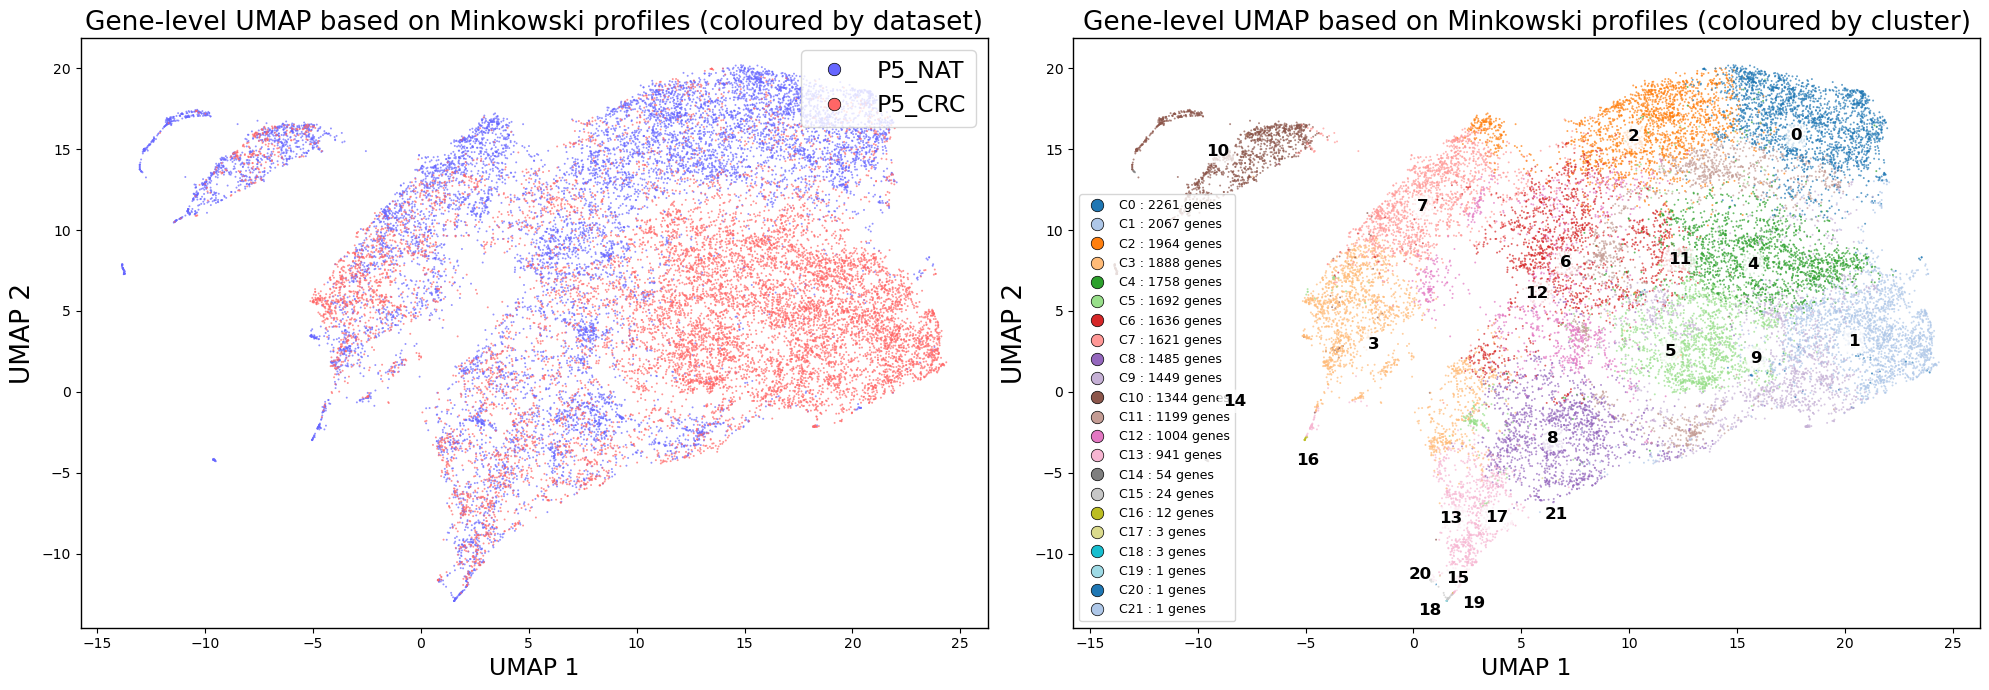

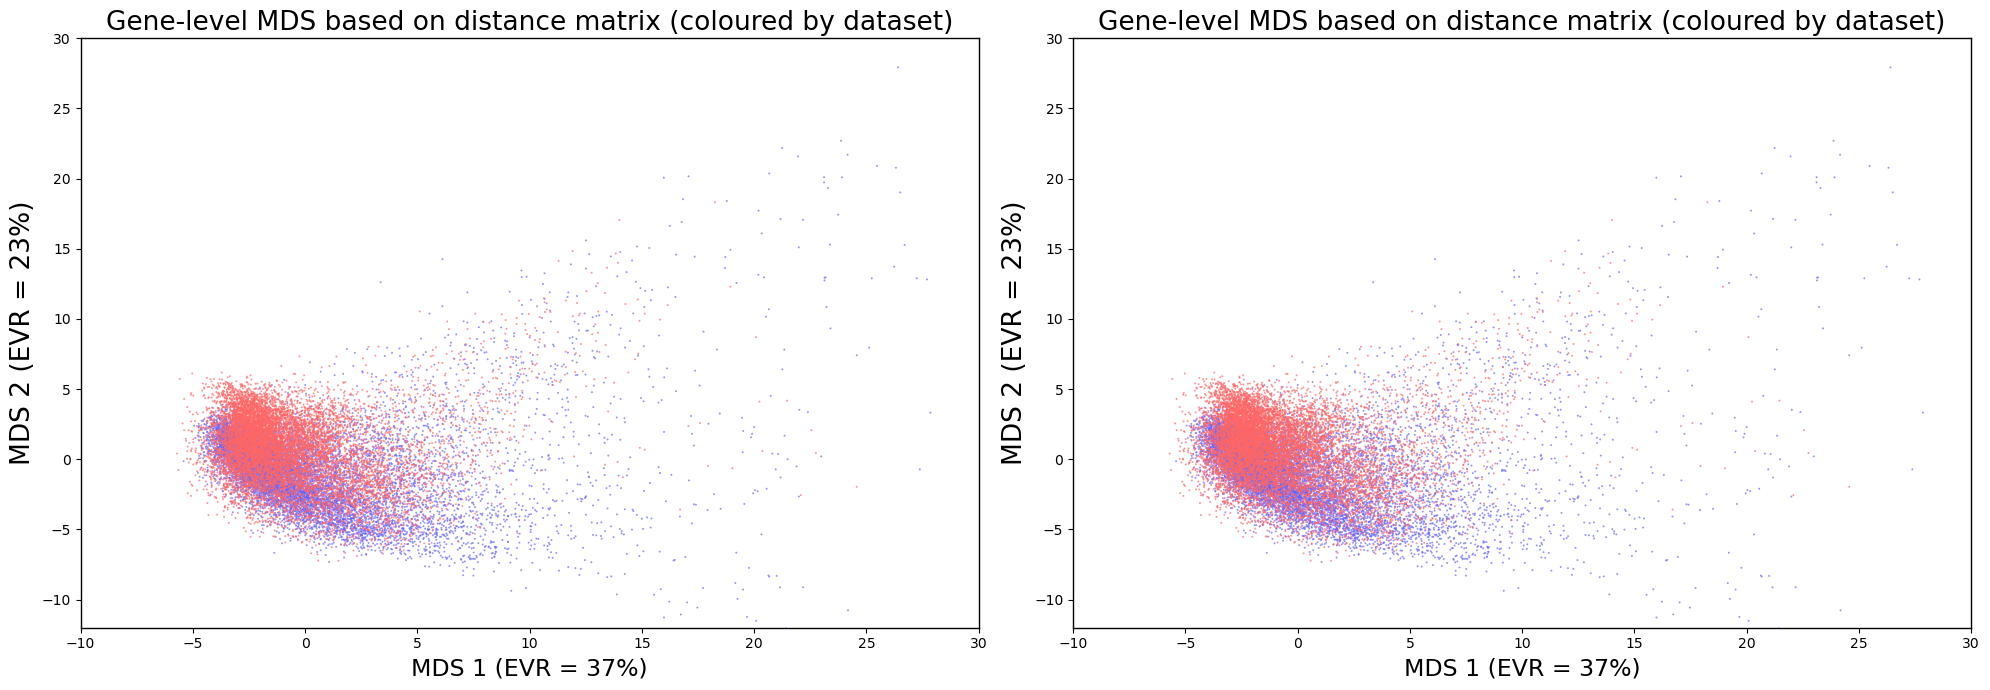

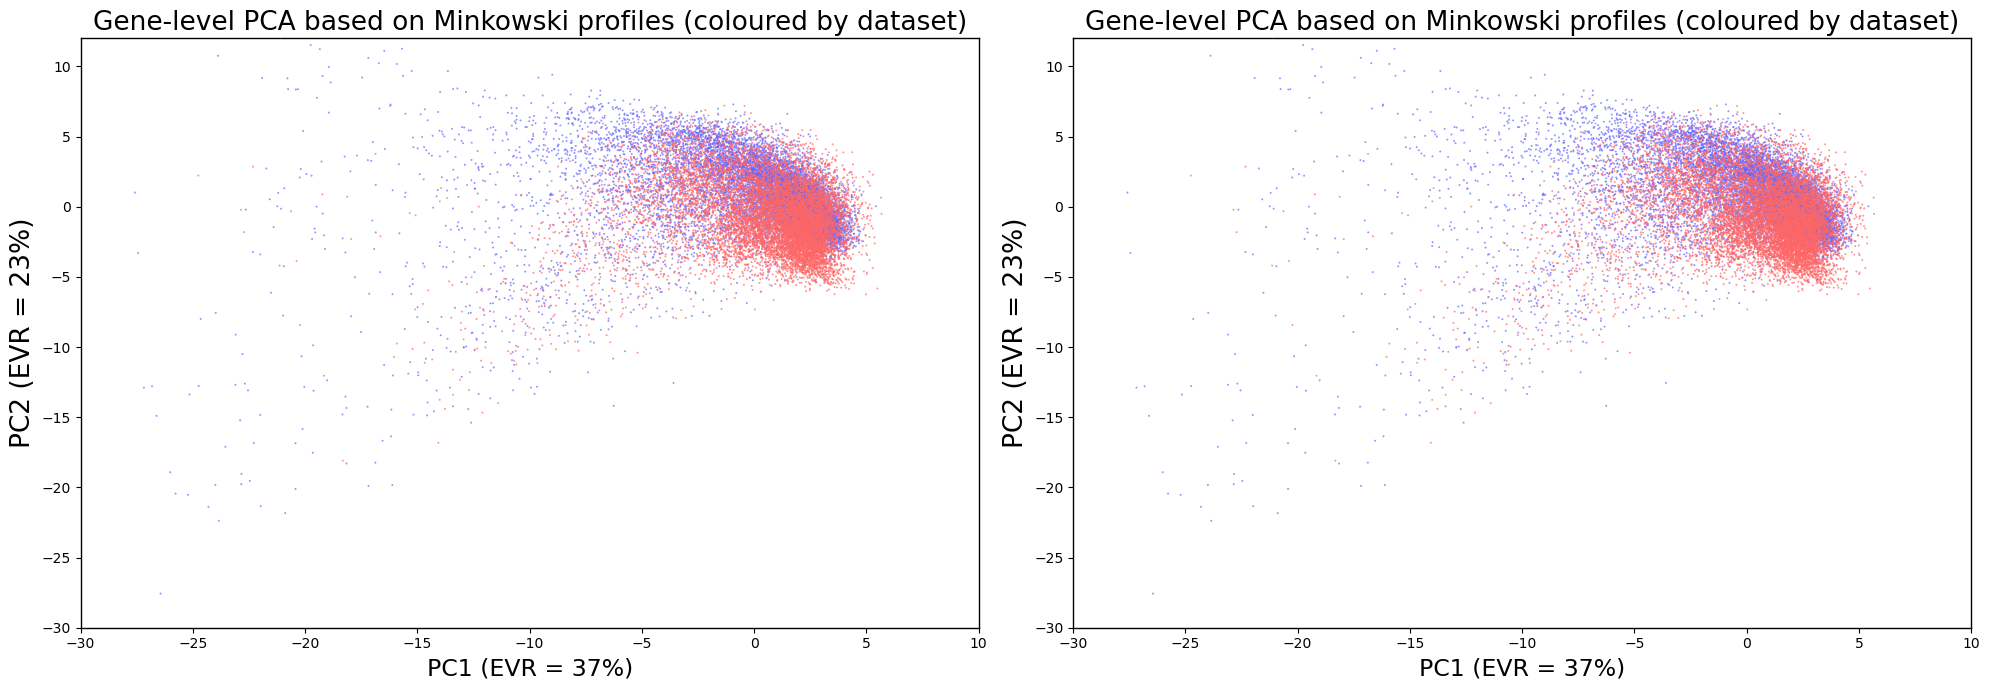

In [8]:
ds_palette_crc = {"P5_NAT": "blue", "P5_CRC": "red"}

res_crc = minkiPy.plot_gene_graphs_from_data(
    data,
    datasets=["P5_NAT", "P5_CRC"],
    graph_mode="knn",
    k=200,
    add_mst=True,
    layout="umap",
    prefer_partition="leiden",
    resolution=0.04,
    edge_mode="mst",
    edge_alpha=0.0,
    node_size=2.0,
    node_alpha=0.7,

    # UMAP
    umap_n_neighbors=10,
    umap_min_dist=0.01,
    umap_spread=3,
    umap_n_components=2,
    umap_init="spectral",
    umap_metric="euclidean",

    # PCA figure options
    make_pca_figure=True,
    #pca_legend_loc_datasets="lower right",
    #pca_legend_loc_clusters="best",

    # GOI
    genes_to_label=None,
    max_gene_labels=0,
    goi_text_size=10.0,
    goi_marker_scale=1.3,
    goi_darken=0.50,
    dataset_palette=ds_palette_crc,
    dataset_lighten=0.40,

    # Legends
    legend_loc_datasets="upper right",
    show_cluster_legend=True,
    cluster_legend_fontsize = 9,
    legend_loc_clusters="lower left",
    

    # Reproducibility
    random_seed=0,

    # View limits
    mds_xlim=(-10, 30),
    mds_ylim=(-12, 30),
    pca_xlim=(-30, 10),
    pca_ylim=(-30, 12),

    # Export
    out_umap_pdf="examples/CRC_dataset/fig5.pdf",
    out_mds_pdf="examples/CRC_dataset/fig6.pdf",
    out_pca_pdf="examples/CRC_dataset/fig7.pdf",
    out_cluster_membership_csv="examples/CRC_dataset/table1.csv",
    print_cluster_info=True,
    mean_density_floatfmt=".2e",
)

## Top genes with the largest spatial change

These cells rank genes by their **same-gene distance** between **P5_CRC** and **P5_NAT**.  
The first plot shows the top-ranked genes overall, while the second restricts the analysis to genes with **moderate log2 fold-change** in normalised density.

[plot_top_changing_genes] W2 percentile lines: p50=5.55043, p90=8.84986, p95=10.8579


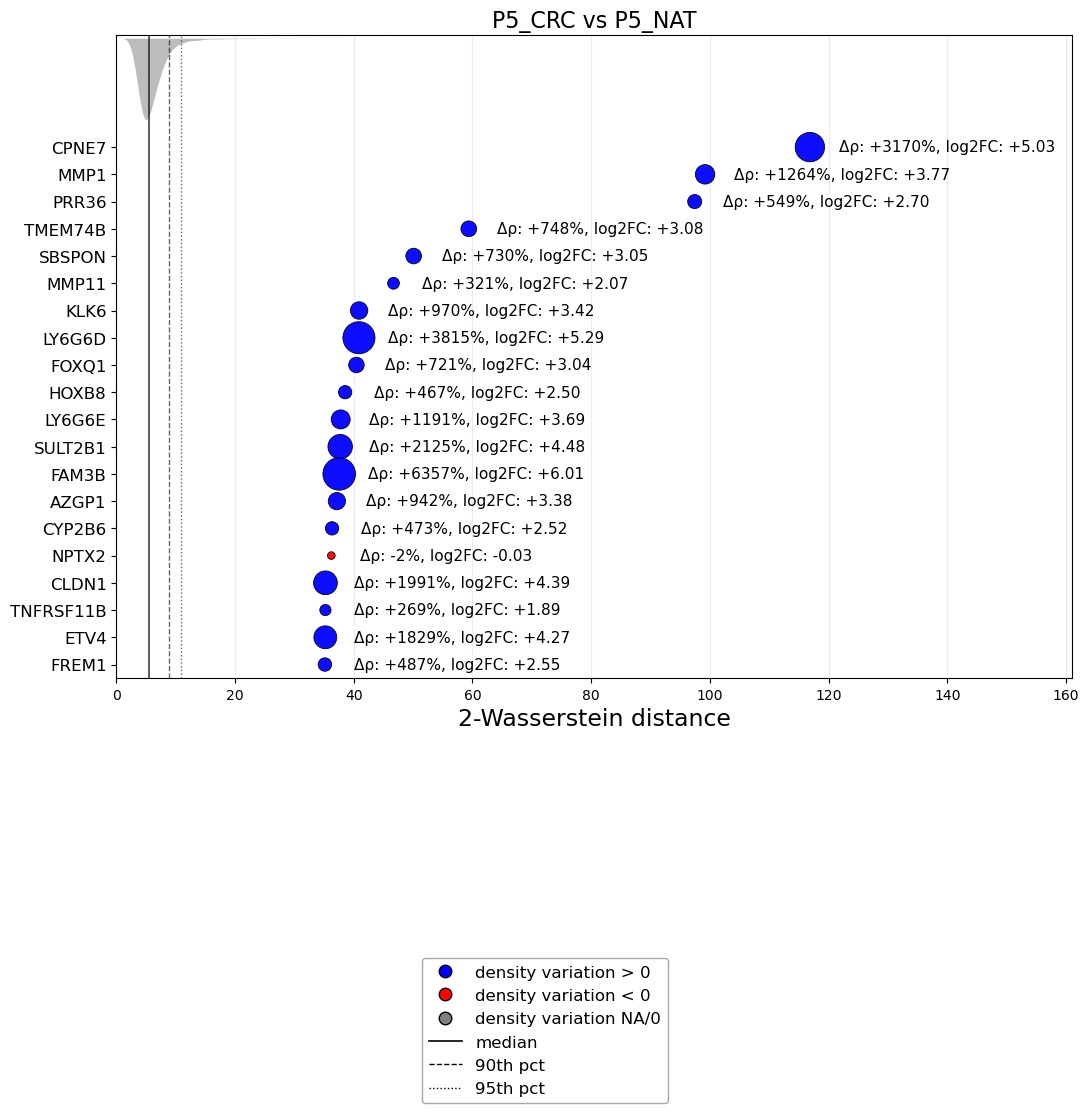

[plot_top_changing_genes] W2 percentile lines: p50=5.46797, p90=8.24149, p95=9.36708


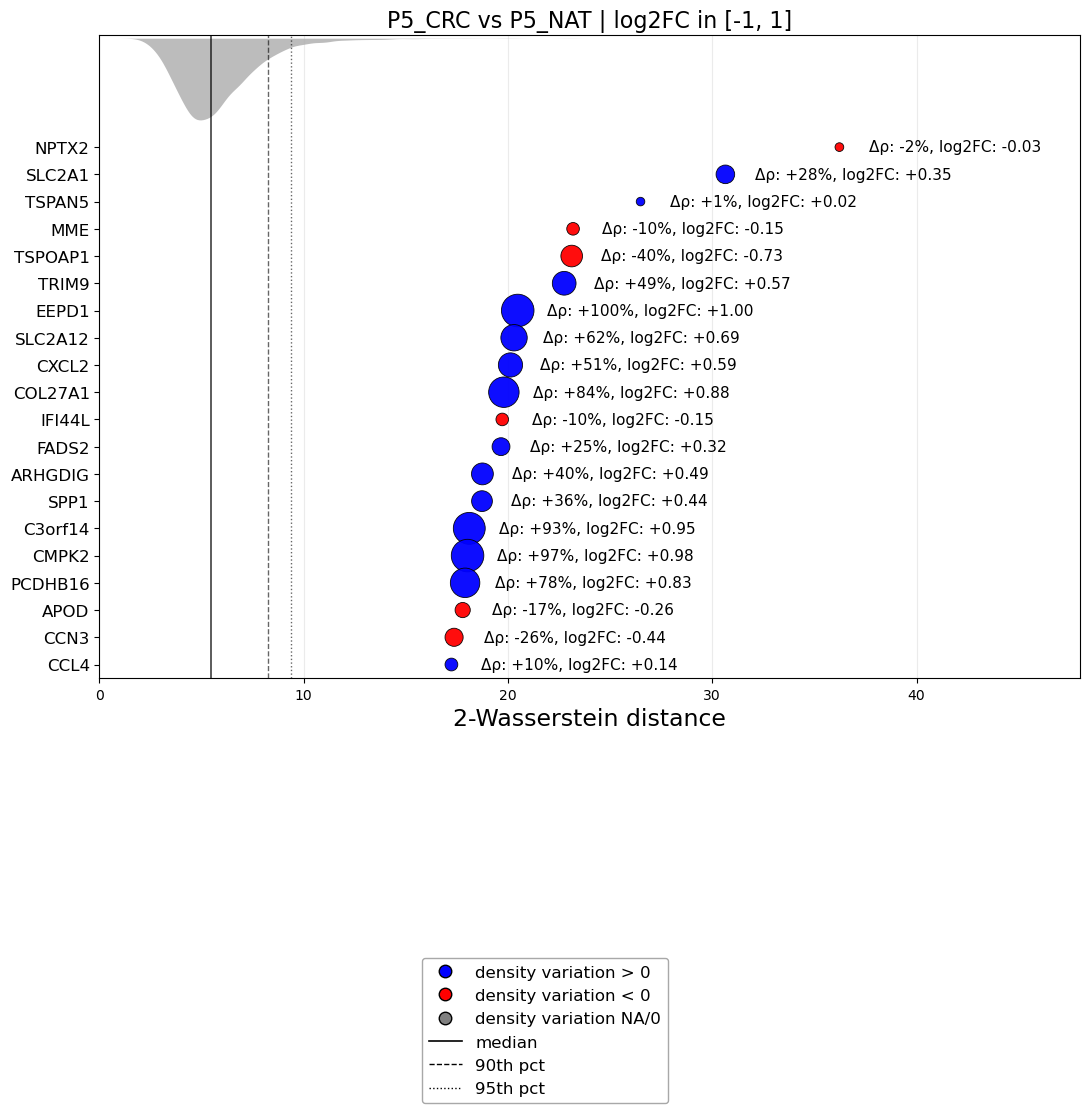

In [9]:
out1 = minkiPy.plot_top_changing_genes(
    data,
    dataset_A="P5_CRC",
    dataset_B="P5_NAT",
    top_k=20,
    save_csv="examples/CRC_dataset/table2.csv",
    save_pdf="examples/CRC_dataset/fig8.pdf",
    xlim_max=161
)

out2 = minkiPy.plot_top_changing_genes(
    data,
    dataset_A="P5_CRC",
    dataset_B="P5_NAT",
    top_k=20,
    log2fc_range=(-1, 1),
    save_csv="examples/CRC_dataset/table3.csv",
    save_pdf="examples/CRC_dataset/fig9.pdf",
    xlim_max=48,
)

## Spatial change versus abundance change

This cell compares the **same-gene Wasserstein distance** with the corresponding **absolute log2 fold-change** in normalised density.  
This provides a simple way to assess how strongly changes in spatial organisation are associated with changes in gene abundance.

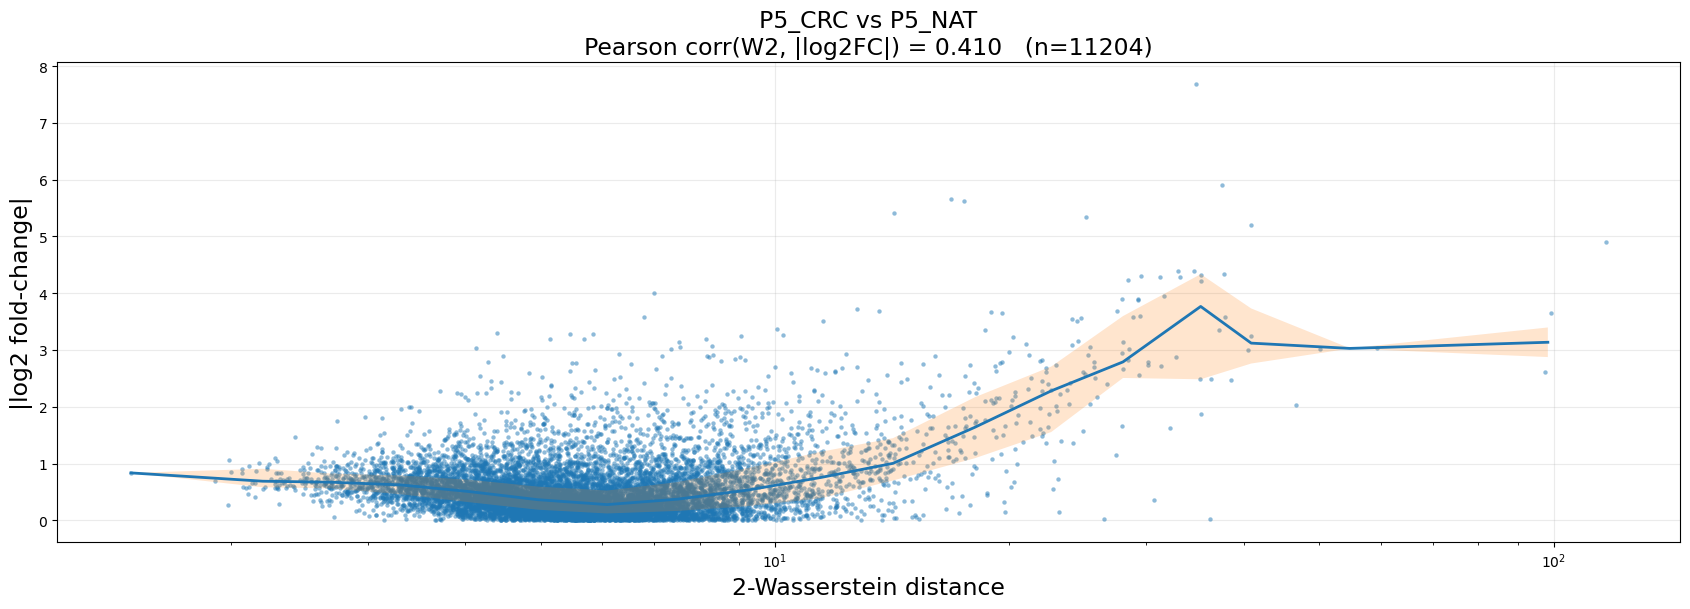

In [10]:
stats = minkiPy.plot_w2_abslog2fc_with_trend(
    data,
    dataset_A="P5_CRC",
    dataset_B="P5_NAT",
    density_field="normalized_density",
    logfc_eps=1e-6,
    xscale="log",
    binning="log",
    nbins=20,
    show_iqr=True,
    show_regression=False,
    save_pdf="examples/CRC_dataset/fig10.pdf",
)